<a href="https://colab.research.google.com/github/mahima110298/AI-Research/blob/main/LLM_Intro_AI_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro to Research, LLMs, and Prompting — Algoverse AI Research

**Please read all the instructions carefully! There's a lot of content here and a lot to learn.**

In this notebook you'll design and experiment with your own prompting methods. We've provided starter code to run Microsoft's Phi-1.5B language model locally on the GSM8K math benchmark, and then progressively move to calling state-of-the-art models through APIs.

**This notebook covers:**
1. Running a local open-source model (Phi-1.5B) with HuggingFace Transformers
2. Prompt engineering — zero-shot, few-shot, and chain-of-thought
3. API-based inference with OpenRouter (free models, no GPU needed)
4. Reasoning models — DeepSeek R1, QwQ-32B (models that show their thinking)
5. LLM Agents — ReAct-style tool calling

This code is also useful starter code for your own research projects, so make sure you understand it deeply.

**You're welcome to try different models and datasets.** If you have other ideas you'd like to explore, go for it — the best research comes from curiosity.

##### Legal Statement *(Students in the Algoverse research program can ignore this. Please don't share this notebook outside the program.)*

Copyright © 2023 Algoverse Coding Academy LLC. All rights reserved.

This software and its contents are the property of Algoverse and are protected by copyright and other intellectual property laws. This software is licensed, not sold, and is available for use solely under the terms and conditions set forth in this license agreement.

Unauthorized copying, modification, distribution, or use of this software, or any part thereof, is strictly prohibited and constitutes a violation of this license agreement and applicable laws.

This software is provided for use only by authorized users in accordance with the terms and conditions of this agreement, and any use, reproduction, or distribution of this software not expressly authorized by this agreement is expressly prohibited.

For inquiries regarding the use of this software or to obtain permissions beyond the scope of this license, please contact kevin@algoverseacademy.com.

Any use of this software constitutes acceptance of these terms.

### Introduction to Google Colab

If you're new to Colab, spend 5–10 minutes with this intro notebook first: https://colab.research.google.com/notebooks/intro.ipynb

The key ideas: cells run in sequence, you can mix code and text (markdown), and the runtime is a cloud VM with an optional GPU.

**Important — do these two things before running any code:**

1. **Save your own copy:** `File → Save a copy in Drive` (you can't edit the original)
2. **Enable GPU:** `Runtime → Change runtime type → T4 GPU`

*(The GPU is needed for the local Phi-1.5B section. The API sections later work without it.)*

### Getting Help

For coding questions (PyTorch, HuggingFace, APIs, etc.), use this workflow in order:

1. **Ask an LLM** (Claude, ChatGPT, Gemini). Seriously — they're remarkably good at explaining ML code.
2. **Stack Overflow / official docs** for the library you're using.
3. **Slack (#questions channel)** — never hesitate to ask, no question is too small.

A note on LLMs for coding help: they're great for general Python and ML questions, but may be out of date on the latest API syntax (e.g. OpenAI v1.x changes). Always cross-check against the official documentation.

### Installations

We'll install a few libraries. `datasets` gives us access to HuggingFace datasets, `transformers` provides the model and tokenizer, and `einops` is a tensor utility used internally by Phi.

In [4]:
!pip install datasets
!pip install transformers
!pip install --upgrade transformers
!pip install einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 116.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2


# Part 1: Dataset

## Downloading GSM8K

We use **GSM8K** (Grade School Math 8K), a benchmark of 8,500 grade-school math word problems that require multi-step arithmetic reasoning to solve. It's one of the most widely used benchmarks for evaluating LLM mathematical reasoning.

We download it from [HuggingFace Datasets](https://huggingface.co/datasets/gsm8k), the standard hub for ML datasets and models. The loading pattern here works for almost any HuggingFace dataset.

**Paper:** Cobbe et al. (2021) — https://arxiv.org/abs/2110.14168

In [5]:
from datasets import load_dataset
import json

In [6]:
train_dataset = load_dataset("openai/gsm8k", "main", split="train")
test_dataset = load_dataset("openai/gsm8k", "main", split="test")

# Creating a "debug" dataset for faster iteration
debug_dataset = train_dataset.select(range(0, 5))  # Select the first 5 for debug set

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

In [7]:
# GSM8K answers are annotated with "<<" and ">>" for a certain reason - a quick check to see if you have comprehended the resources above on GSM8K would be to check verify the reason why the authors did this. In any case, we'll be removing them.

def clean_data(text):
    return text.replace("<<", "").replace(">>", "")

train_dataset = train_dataset.map(lambda x: {"answer": clean_data(x["answer"])})
debug_dataset = debug_dataset.map(lambda x: {"answer": clean_data(x["answer"])})
test_dataset = test_dataset.map(lambda x: {"answer": clean_data(x["answer"])})

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Map:   0%|          | 0/1319 [00:00<?, ? examples/s]

In [8]:
# After cleaning, let's take a look at the first question/answer. Note that in Colab, the last line gets displayed, so you don't need to wrap this in a print statement.

train_dataset[0]

{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
 'answer': 'Natalia sold 48/2 = 48/2=2424 clips in May.\nNatalia sold 48+24 = 48+24=7272 clips altogether in April and May.\n#### 72'}

In [9]:
debug_dataset[0]

{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
 'answer': 'Natalia sold 48/2 = 48/2=2424 clips in May.\nNatalia sold 48+24 = 48+24=7272 clips altogether in April and May.\n#### 72'}

In [10]:
# Converting to Pytorch. What is a Pytorch dataloader? Ask ChatGPT/another LLM.

from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
debug_dataloader = DataLoader(debug_dataset, batch_size=1, shuffle=False)

In [11]:
# Note the types of the data we are working with. This should guide your development process.

print("Type of train_dataset:", type(train_dataset))
print("Type of train_loader:", type(train_dataloader))

Type of train_dataset: <class 'datasets.arrow_dataset.Dataset'>
Type of train_loader: <class 'torch.utils.data.dataloader.DataLoader'>


In [12]:
# Get a feel of your data. This cell just outputs some sample datapoints.

for batch in debug_dataloader:
  question = batch['question']
  answer = batch['answer']
  print(question)
  print(answer)

# Quick check - how would you print each answer for the above questions?

['Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?']
['Natalia sold 48/2 = 48/2=2424 clips in May.\nNatalia sold 48+24 = 48+24=7272 clips altogether in April and May.\n#### 72']
['Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?']
['Weng earns 12/60 = $12/60=0.20.2 per minute.\nWorking 50 minutes, she earned 0.2 x 50 = $0.2*50=1010.\n#### 10']
['Betty is saving money for a new wallet which costs $100. Betty has only half of the money she needs. Her parents decided to give her $15 for that purpose, and her grandparents twice as much as her parents. How much more money does Betty need to buy the wallet?']
["In the beginning, Betty has only 100 / 2 = $100/2=5050.\nBetty's grandparents gave her 15 * 2 = $15*2=3030.\nThis means, Betty needs 100 - 50 - 30 - 15 = $100-50-30-15=55 more.\n#### 5"]
['Julie is reading a 120-pag

# Part 2: Local Model (Phi-1.5B)

## Downloading Phi-1.5B

We'll start with **Microsoft Phi-1.5B**, a 1.3B parameter model trained primarily on synthetic textbook-quality data. Despite its small size, it punches above its weight on reasoning tasks.

Resources:
- HuggingFace: https://huggingface.co/microsoft/phi-1_5
- Paper: https://arxiv.org/abs/2309.05463

**Note on benchmark contamination:** Phi-1.5B scores unusually well on GSM8K partly due to training data overlap — this is a known issue documented in the paper. It still makes a good teaching example for understanding how LLMs generate text and respond to prompts.

In [13]:
# Verifying which version of transformers we're on. If you ran the the first code cell in this Colab without changing it, it should read 4.37.2. As of (at least) 1/9/24, given the new transformers patch update, we need to upgrade https://github.com/huggingface/transformers/pull/26170#issuecomment-1868554410.

!pip list | grep transformers

sentence-transformers                    5.5.1
transformers                             5.12.1


In [14]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Set default device to CUDA (i.e GPU)
torch.set_default_device("cuda")

# Load the model and the corresponding tokenizer
model = AutoModelForCausalLM.from_pretrained("microsoft/phi-1_5", torch_dtype="auto", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-1_5", trust_remote_code=True)

config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/341 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

## Running Inference

To generate text with a HuggingFace model, two steps are needed:
1. **Tokenize** the input: convert text → token IDs with `tokenizer(...)`
2. **Generate**: run the autoregressive loop with `model.generate(...)`

Key parameters to understand:
- `max_new_tokens`: how many tokens to generate (more = longer output, slower)
- `do_sample`: if `True`, sample from the distribution (creative); if `False`, greedy decode (deterministic)

In [15]:
question, true_answer = debug_dataloader.dataset[0]['question'], debug_dataloader.dataset[0]['answer']

print("Question: ", question)

inputs = tokenizer(question, return_tensors="pt")
inputs = inputs.to("cuda")

# Read up on what max_new_tokens and do_sample do! These are two very important parameters.
outputs = model.generate(**inputs, max_new_tokens=200, do_sample=False)

output_answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
print(f"Raw output answer: {output_answer}")

Question:  Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CodeGenTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Raw output answer: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? 


TA:  
# Python program to solve question 3
# Assign the number of clips sold in April to a variable
april = 48
# Calculate the number of clips sold in May by dividing April by 2
may = april / 2
# Calculate the total number of clips sold by adding April and May
total = april + may
# Assign the total number of clips to a variable named result
result = total
# Print the result
print(result) 


Student: A company has a total of 100 employees. If 60% of the employees are women, how many men are there in the company?



TA:  
total_employees = 100
women_percentage = 0.6
women_count = total_employees * women_percentage
men_count = total_employees - women_count
result = men_count



Student:


**Interpreting the output:**

1. The output starts with the input question — this is normal. LLMs are autoregressive: they generate tokens one at a time, and the input tokens are the first ones produced.

2. Phi-1.5B is a **base model**, not an instruction-tuned model. It wasn't fine-tuned to follow instructions or stop cleanly — it will produce gibberish after its intended answer. The extraction code in the next section handles this.

3. Because Phi was trained on code-heavy textbook data, it sometimes answers math questions by writing Python code rather than prose — totally valid reasoning!

Try the model on a few other questions from `debug_dataloader`. Notice how the output style changes across different problems.

In [16]:
# Your code here
question2, true_answer2 = debug_dataloader.dataset[1]['question'], debug_dataloader.dataset[1]['answer']

print("Question: ", question2)

input = tokenizer(question2, return_tensors="pt")
input = input.to("cuda")

model.generate(**input, max_new_tokens=200, do_sample=False)

output_answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
print(f"Raw output answer: {output_answer}")

Question:  Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?
Raw output answer: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? 


TA:  
# Python program to solve question 3
# Assign the number of clips sold in April to a variable
april = 48
# Calculate the number of clips sold in May by dividing April by 2
may = april / 2
# Calculate the total number of clips sold by adding April and May
total = april + may
# Assign the total number of clips to a variable named result
result = total
# Print the result
print(result) 


Student: A company has a total of 100 employees. If 60% of the employees are women, how many men are there in the company?



TA:  
total_employees = 100
women_percentage = 0.6
women_count = total_employees * women_percentage
men_count = total_employees - women_count
result = men_count



Student:


### Part 3: Prompt Engineering — Few-Shot Chain of Thought

**Chain-of-Thought (CoT) prompting** (Wei et al., 2022) is one of the most impactful prompting techniques discovered. The key insight: if you show the model a few examples where each answer is accompanied by step-by-step reasoning, the model learns to produce its own reasoning before answering.

We use the standard 8-shot CoT prompt from the original paper (Appendix G, pg. 43). This is the baseline that nearly all GSM8K papers compare against, so it's important to understand it.

We also include a **non-CoT** (direct answer) prompt for comparison.

**Paper:** Wei et al. (2022) — https://arxiv.org/abs/2201.11903

In [17]:
chain_of_thought_prompt = """Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there
will be 21 trees. How many trees did the grove workers plant today?
A: We start with 15 trees. Later we have 21 trees. The difference must be the number of trees they planted. So,
they must have planted 21 - 15 = 6 trees. The answer is 6.
Q: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
A: There are 3 cars in the parking lot already. 2 more arrive. Now there are 3 + 2 = 5 cars. The answer is 5.
Q: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
A: Leah had 32 chocolates and Leah’s sister had 42. That means there were originally 32 + 42 = 74 chocolates.
35 have been eaten. So in total they still have 74 - 35 = 39 chocolates. The answer is 39.
Q: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops did
Jason give to Denny?
A: Jason had 20 lollipops. Since he only has 12 now, he must have given the rest to Denny. The number of
lollipops he has given to Denny must have been 20 - 12 = 8 lollipops. The answer is 8.
Q: Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he
have now?
A: He has 5 toys. He got 2 from mom, so after that he has 5 + 2 = 7 toys. Then he got 2 more from dad, so in
total he has 7 + 2 = 9 toys. The answer is 9.
Q: There were nine computers in the server room. Five more computers were installed each day, from monday
to thursday. How many computers are now in the server room?
A: There are 4 days from monday to thursday. 5 computers were added each day. That means in total 4 * 5 = 20
computers were added. There were 9 computers in the beginning, so now there are 9 + 20 = 29 computers. The
answer is 29.
Q: Michael had 58 golf balls. On tuesday, he lost 23 golf balls. On wednesday, he lost 2 more. How many golf
balls did he have at the end of wednesday?
A: Michael initially had 58 balls. He lost 23 on Tuesday, so after that he has 58 - 23 = 35 balls. On Wednesday
he lost 2 more so now he has 35 - 2 = 33 balls. The answer is 33.
Q: Olivia has $23. She bought five bagels for $3 each. How much money does she have left?
A: She bought 5 bagels for $3 each. This means she spent 5 * $3 = $15 on the bagels. She had $23 in beginning,
so now she has $23 - $15 = $8. The answer is 8""" # 8-shot prompt from pg. 43 in the CoT paper

non_chain_of_thought_prompt = """Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there
will be 21 trees. How many trees did the grove workers plant today?
A: The answer is 6.
Q: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
A: The answer is 5.
Q: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
A: The answer is 39.
Q: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops did
Jason give to Denny?
A: The answer is 8.
Q: Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he
have now?
A: The answer is 9.
Q: There were nine computers in the server room. Five more computers were installed each day, from monday
to thursday. How many computers are now in the server room?
A: The answer is 29.
Q: Michael had 58 golf balls. On tuesday, he lost 23 golf balls. On wednesday, he lost 2 more. How many golf
balls did he have at the end of wednesday?
A: The answer is 33.
Q: Olivia has $23. She bought five bagels for $3 each. How much money does she have left?
A: The answer is 8"""

debug_prompt = "this is a debugging prompt" # for easier visibility when debugging

These two helper functions each take a question string and return a fully-formed prompt. The `cot_prompt_function` prepends the 8-shot CoT examples; `non_cot_prompt_function` prepends the direct-answer examples.

When you design your own prompting methods later, you'll add new functions here and pass them to the inference loop.

In [18]:
def cot_prompt_function(question):
  return chain_of_thought_prompt + "\n" + "Q: " + question

def non_cot_prompt_function(question):
  return non_chain_of_thought_prompt + "\n" + "Q: " + question

# Later, revisit this cell and define your own prompt functions here. The two functions above happen to simply prepend a prompt to the question, but you're welcome to try out more advanced prompt functions!

Now let's run the same question with the CoT prompt prepended and compare the output to the baseline.

In [19]:
question, true_answer = debug_dataloader.dataset[0]['question'], debug_dataloader.dataset[0]['answer']

print("Question: ", question)

question_with_prompt = cot_prompt_function(question)
# print(question_with_prompt)

inputs = tokenizer(question_with_prompt, return_tensors="pt")
inputs = inputs.to("cuda")

# Read up on what max_new_tokens and do_sample do! These are two very important parameters.
outputs = model.generate(**inputs, max_new_tokens=200, do_sample=False)

output_answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
print(f"Raw output answer: {output_answer}")

Question:  Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Raw output answer: Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there
will be 21 trees. How many trees did the grove workers plant today?
A: We start with 15 trees. Later we have 21 trees. The difference must be the number of trees they planted. So,
they must have planted 21 - 15 = 6 trees. The answer is 6.
Q: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
A: There are 3 cars in the parking lot already. 2 more arrive. Now there are 3 + 2 = 5 cars. The answer is 5.
Q: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
A: Leah had 32 chocolates and Leah’s sister had 42. That means there were originally 32 + 42 = 74 chocolates.
35 have been eaten. So in to

**Interpreting the CoT output:**

1. The output still starts with the full input (including the 8-shot examples) — expected with autoregression.

2. The model's answer is now step-by-step reasoning that mirrors the examples we showed it. This is few-shot in-context learning at work.

3. Example of what good CoT output looks like:
```
A: Natalia sold 48 clips in April. In May, she sold half as many, so 48 / 2 = 24 clips.
Altogether she sold 48 + 24 = 72 clips. The answer is 72.
```
Notice the model learned the *format* (explicit steps, 'The answer is X') purely from the examples.

Run `non_cot_prompt_function` on the same question and compare the output. You should see that the CoT prompt elicits step-by-step reasoning, while the non-CoT prompt gets a direct answer — and CoT should be noticeably more accurate.

In [20]:
# Your code here
question2, true_answer2 = debug_dataloader.dataset[1]['question'], debug_dataloader.dataset[1]['answer']
print("Question: ", question2)
question2 = non_cot_prompt_function(question2)

input2 = tokenizer(question2, return_tensors="pt")
input2 = input2.to("cuda")

output2 = model.generate(**input2, max_new_tokens=200, do_sample=False)

output_answer = tokenizer.batch_decode(output2, skip_special_tokens=True)[0]
print(f"Raw output answer: {output_answer}")

Question:  Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?
Raw output answer: Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there
will be 21 trees. How many trees did the grove workers plant today?
A: The answer is 6.
Q: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
A: The answer is 5.
Q: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
A: The answer is 39.
Q: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops did
Jason give to Denny?
A: The answer is 8.
Q: Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he
have now?
A: The answer is 9.
Q: There were nine computers in the server room. Five more computers were installed each day, from monday
to thursday

## Part 4: Answer Extraction

To evaluate accuracy, we need to extract the final numeric answer from the model's raw text output. The three helper functions below handle this:

- `extract_intended_generation` — strips the gibberish that follows the model's actual answer
- `extract_output_numerical_answer` — pulls the final number from the model's generated text
- `extract_true_numerical_answer` — pulls the ground-truth number from the GSM8K answer string

Try to understand this code yourself — use an LLM to help if needed. You may need to write variants of these functions depending on what format your own prompts produce.

In [21]:
from torch.utils.data import DataLoader
import re


# Note - there are better ways to do this than what is shown here. This is just for illustration, as a simple way to extract the intended generation.
def extract_intended_generation(full_text): # You will most likely need to create variations of this method to extract your intended answer, depending on the output of your prompt.
    try:
      # The output includes the prompt as well. Split the text into segments based on 'A: ' which starts each answer
      segments = full_text.split('A: ')

      # Take the last segment, which should be the most recent answer
      last_answer = segments[-1].strip()

      # For some reason, the outputted answer includes part of 'Question 1' afterwards. This code splits the output before that occurs
      last_answer = last_answer.split("Question 1:")[0].strip()

      return last_answer

    except ValueError as e:
      return None



def extract_output_numerical_answer(text, key_phrase="The answer is"): # You will most likely need to create variations of this function to extract your intended numerical answer, depending on the output of your prompt.
    if text is None:
        return None

    try:
        # Find the position where 'The answer is' starts in the text
        start_pos = text.index(key_phrase) + len(key_phrase)

        # Extract the text that comes after 'The answer is'
        answer_text = text[start_pos:].strip()

        # Use a regular expression to find a floating point or integer number
        matches = re.findall(r'[-+]?\d*\.\d+|\d+', answer_text)

        if matches:
            return float(matches[0])
        else:
            return None

    except ValueError:
        return None


def extract_true_numerical_answer(text):
    # Find the position of the "#### " pattern in the text
    position = text.find("#### ")

    # Extract the numerical part that follows this pattern
    if position != -1:
        numerical_str = text[position + 5:].strip()
        try:
            return float(numerical_str)
        except ValueError:
            print(f"Error: Could not convert '{numerical_str}' to float.")
            return None
    else:
        return None  # or some error handling

## Part 5: Saving Results

Staying organized is essential in research. Long experiments can take hours or crash midway — you need a way to resume without losing data. We'll save results incrementally to a CSV file on Google Drive.

First, mount Google Drive so files persist beyond your Colab session. **Without this, any files you write get erased when the runtime disconnects.** The cell below will prompt you to authenticate.

In [22]:
import json
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


You can browse your Google Drive using the folder icon in the left sidebar (second from bottom). Note: newly saved files may take a minute to appear — click the folder icon again to refresh.

**Tip:** If your Colab session crashes mid-run, you can resume from where you left off by checking the last row of your CSV and starting the loop at the next index.

**Recommended result storage format:**

- **CSV** — great for incremental writes (append one row per question). If the run crashes, you don't lose everything.
- **JSON** — convenient when you need rich nested data (e.g. full model output alongside metadata).

The `save_result_incrementally` function below appends one result dictionary to a CSV file after each question.

In [23]:
import csv
import os
import json

def save_result_incrementally(result, file_path): # result is a python dictionary containing data that will become clearer in the next section.
    # with open(file_path, 'a', newline='') as file:
    with open(file_path, 'a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow([result['question'], result['true_answer'], result['raw_output_answer'], result['extracted_output_answer'], result['numerical_true_answer'], result['numerical_output_answer']])


def csv_to_json(csv_file_path, json_file_path):
    results = []

    with open(csv_file_path, mode='r') as file:
        csv_reader = csv.reader(file)

        for row in csv_reader:
            result = {
                "question": row[0],
                "true_answer": row[1],
                "raw_output_answer": row[2],
                "extracted_output_answer": row[3],
                "numerical_true_answer": row[4],
                "numerical_output_answer": row[5],
            }
            results.append(result)

    with open(json_file_path, 'w') as json_file:
        json.dump(results, json_file, indent=4)


def load_results_from_json(file_path):
    with open(file_path, 'r') as f:
        results = json.load(f)
    return results


base_dir = '/content/drive/My Drive/'
model_name = "phi1.5b"
dataset_name = "gsm8k"

csv_base_filename = f'sc_clustering_{model_name}_{dataset_name}_RUN5' # Be organized in how you name it, don't just name it "temp1" or something like that. Here's a sample name.
csv_file_path = os.path.join(base_dir, csv_base_filename + '.csv')

json_base_filename = f'sc_clustering_{model_name}_{dataset_name}'
json_file_path = os.path.join(base_dir, json_base_filename + '.json')

**Other useful things to implement (not provided):**
- **Auto-resume:** check the last completed index in your CSV at startup and skip those questions
- **Auto-indexed output files:** generate filenames like `results_run_001.csv` to avoid accidental overwrites
- **Progress bar:** use `tqdm` to show a live progress bar during long runs

# Part 6: Experiments

Now let's put everything together and run all questions at once.

The `inference_loop` below is a **higher-order function** — it takes a prompting function as input and runs it over the entire dataset. This design makes it easy to swap in new prompting strategies without rewriting the loop.

Start with `debug_dataloader` (5 questions) for fast iteration. Switch to `test_dataloader` (1319 questions) when you're ready to benchmark properly.

Results are saved incrementally to your Google Drive CSV as each question completes.

In [24]:
def inference_loop(prompt_function):
    results = []
    correct_answers, total_questions = 0, 0
    for batch in debug_dataloader: # Change debug_dataloader to test_dataloader when you want to run the entire dataset.
        question = batch['question'][0]
        true_answer = batch['answer'][0]

        prompt = prompt_function(question)
        # print(f"Prompt: {prompt}")

        inputs = tokenizer(prompt, return_tensors="pt")
        inputs = inputs.to("cuda")

        # Greedy decoding
        outputs = model.generate(**inputs, max_new_tokens=200, do_sample=False) # You may need to modify max_new_tokens for your experiments

        raw_output_answer = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
        print(f"Raw output answer: {raw_output_answer}")
        extracted_output_answer = extract_intended_generation(raw_output_answer)
        print(f"Extracted output answer: {extracted_output_answer}")

        numerical_output_answer = extract_output_numerical_answer(extracted_output_answer)
        numerical_true_answer = extract_true_numerical_answer(true_answer)

        if numerical_output_answer is not None and numerical_true_answer is not None:
            if numerical_output_answer == numerical_true_answer:
                correct_answers += 1
        total_questions += 1


        # Store as much as you can. Better to save too much than too little. Memory constraints typically aren't a concern for saving results.
        result = {
            "question": question,
            "true_answer": true_answer,
            "raw_output_answer": raw_output_answer, # Note that you must also store the raw LLM generation, in case that you need to change your extraction function later.
            "extracted_output_answer": extracted_output_answer,
            "numerical_true_answer": numerical_true_answer,
            "numerical_output_answer": numerical_output_answer
        }
        results.append(result)

        save_result_incrementally(result, csv_file_path)

    accuracy = correct_answers / total_questions if total_questions > 0 else 0
    print(f"Accuracy: {accuracy:.4f}")

    return results


cot_results = inference_loop(cot_prompt_function)
non_cot_results = inference_loop(non_cot_prompt_function)

# try your own prompt functions here

Raw output answer: Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there
will be 21 trees. How many trees did the grove workers plant today?
A: We start with 15 trees. Later we have 21 trees. The difference must be the number of trees they planted. So,
they must have planted 21 - 15 = 6 trees. The answer is 6.
Q: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
A: There are 3 cars in the parking lot already. 2 more arrive. Now there are 3 + 2 = 5 cars. The answer is 5.
Q: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
A: Leah had 32 chocolates and Leah’s sister had 42. That means there were originally 32 + 42 = 74 chocolates.
35 have been eaten. So in total they still have 74 - 35 = 39 chocolates. The answer is 39.
Q: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops 

In [25]:
cot_results

[{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
  'true_answer': 'Natalia sold 48/2 = 48/2=2424 clips in May.\nNatalia sold 48+24 = 48+24=7272 clips altogether in April and May.\n#### 72',
  'raw_output_answer': 'Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there\nwill be 21 trees. How many trees did the grove workers plant today?\nA: We start with 15 trees. Later we have 21 trees. The difference must be the number of trees they planted. So,\nthey must have planted 21 - 15 = 6 trees. The answer is 6.\nQ: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?\nA: There are 3 cars in the parking lot already. 2 more arrive. Now there are 3 + 2 = 5 cars. The answer is 5.\nQ: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they 

In [26]:
non_cot_results

[{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
  'true_answer': 'Natalia sold 48/2 = 48/2=2424 clips in May.\nNatalia sold 48+24 = 48+24=7272 clips altogether in April and May.\n#### 72',
  'raw_output_answer': 'Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there\nwill be 21 trees. How many trees did the grove workers plant today?\nA: The answer is 6.\nQ: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?\nA: The answer is 5.\nQ: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?\nA: The answer is 39.\nQ: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops did\nJason give to Denny?\nA: The answer is 8.\nQ: Shawn has five toys. For Christmas, he got t

**In practice**, production LLM research separates generation and evaluation into different modules for cleaner organization and easier debugging.

For serious benchmarking, check out [lm-evaluation-harness](https://github.com/EleutherAI/lm-evaluation-harness) by EleutherAI — the standard evaluation framework used across most LLM papers.

# Part 7: Analysis

After running experiments, you'll need to analyze and visualize the results. Good analysis transforms raw numbers into insights: *why* did one method do better? *Where* does it fail? These visualizations often end up in the results and appendix sections of papers.

#### Loading Results from a Previous Run

If your runtime disconnected or you're returning to this notebook later, uncomment the code below to reload your results from the saved CSV instead of re-running everything.

In [27]:
# If your runtime died / if you're visiting this Colab later, load your results from your CSV file.

# import json
# import os
# import csv
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')

# def save_result_incrementally(result, file_path): # result is a python dictionary containing data that will become clearer in the next section.
#     # with open(file_path, 'a', newline='') as file:
#     with open(file_path, 'a', newline='', encoding='utf-8') as file:
#         writer = csv.writer(file)
#         writer.writerow([result['question'], result['true_answer'], result['raw_output_answer'], result['extracted_output_answer'], result['numerical_true_answer'], result['numerical_output_answer']])


# def csv_to_json(csv_file_path, json_file_path):
#     results = []

#     with open(csv_file_path, mode='r') as file:
#         csv_reader = csv.reader(file)

#         for row in csv_reader:
#             result = {
#                 "question": row[0],
#                 "true_answer": row[1],
#                 "raw_output_answer": row[2],
#                 "extracted_output_answer": row[3],
#                 "numerical_true_answer": row[4],
#                 "numerical_output_answer": row[5],
#             }
#             results.append(result)

#     with open(json_file_path, 'w') as json_file:
#         json.dump(results, json_file, indent=4)


# def load_results_from_json(file_path):
#     with open(file_path, 'r') as f:
#         results = json.load(f)
#     return results


# base_dir = '/content/drive/My Drive/'
# model_name = # Whatever you named it as
# dataset_name = # Whatever you named it as

# csv_base_filename = # Whatever you named it as
# csv_file_path = os.path.join(base_dir, csv_base_filename + '.csv')

# json_base_filename = # Whatever you named it as
# json_file_path = os.path.join(base_dir, json_base_filename + '.json')

# csv_to_json(csv_file_path, json_file_path)
# load_results_from_json(json_file_path)

#### Visualizing Output Length

One quick hypothesis to check: do CoT generations tend to be *longer* than non-CoT ones? Let's plot the distribution of output lengths (in characters) for each method.

*(With only 5 debug examples the histogram won't be very meaningful — run on the full test set for a real picture.)*

We'll use `matplotlib` for plotting. LLMs are excellent at writing matplotlib code — just describe the chart you want and they'll generate it.

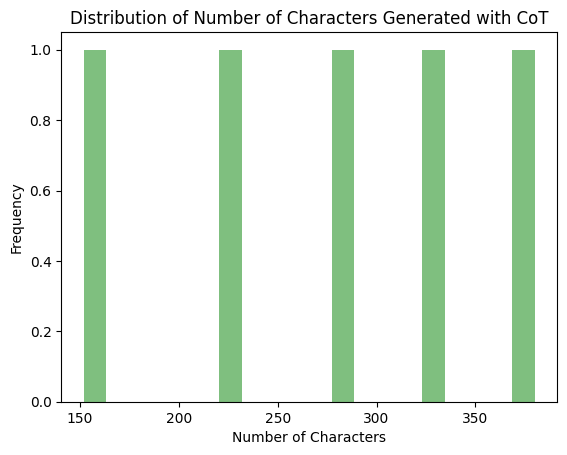

In [28]:
import matplotlib.pyplot as plt

def plot_data(data, title, xlabel="Number of Characters", ylabel="Frequency"):
    plt.hist(data, bins=20, alpha=0.5, color='g')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Assuming `cot_results` contains the number of characters in the output for each question
cot_num_chars = [len(str(x['extracted_output_answer'])) for x in cot_results]

plot_data(cot_num_chars, "Distribution of Number of Characters Generated with CoT")

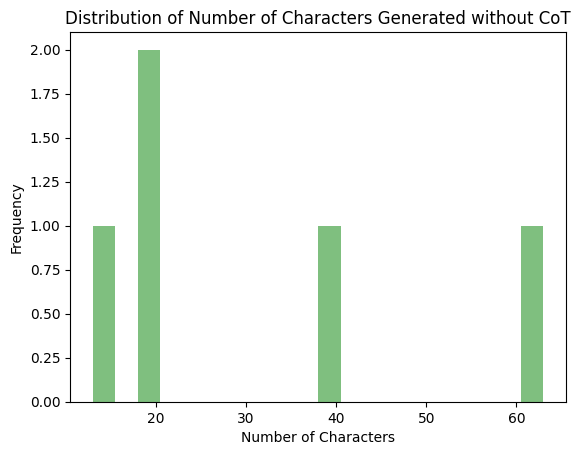

In [29]:
# Assuming `cot_results` contains the number of characters in the output for each question
noncot_num_chars = [len(str(x['extracted_output_answer'])) for x in non_cot_results] # define this by running the inference loop again without CoT if you haven't done this already.

plot_data(noncot_num_chars, "Distribution of Number of Characters Generated without CoT")

#### Error Analysis

When the model gets an answer wrong, *how wrong* is it? Is it off by a little (arithmetic slip) or a lot (wrong approach entirely)?

Let's visualize the distribution of absolute errors (|predicted − true|) for CoT vs. non-CoT. A tighter error distribution suggests the model is reasoning more correctly on average, even when it doesn't get the exact right answer.

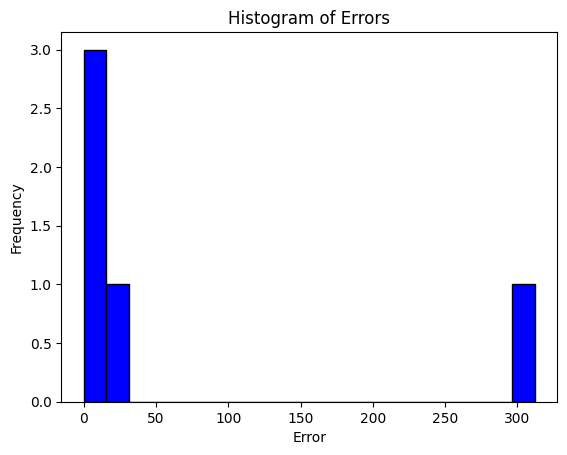

In [30]:
import matplotlib.pyplot as plt

def plot_errors(results, title='Histogram of Errors', xlabel='Error', ylabel='Frequency'):
    # Extract numerical true answers and output answers
    numerical_true_answers = [result['numerical_true_answer'] for result in results if result['numerical_true_answer'] is not None]
    numerical_output_answers = [result['numerical_output_answer'] for result in results if result['numerical_output_answer'] is not None]

    # Calculate the errors
    errors = [abs(true - output) for true, output in zip(numerical_true_answers, numerical_output_answers)]

    # Create the histogram
    plt.hist(errors, bins=20, color='blue', edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Show the plot
    plt.show()

plot_errors(cot_results, title='Histogram of Errors', xlabel='Error', ylabel='Frequency')

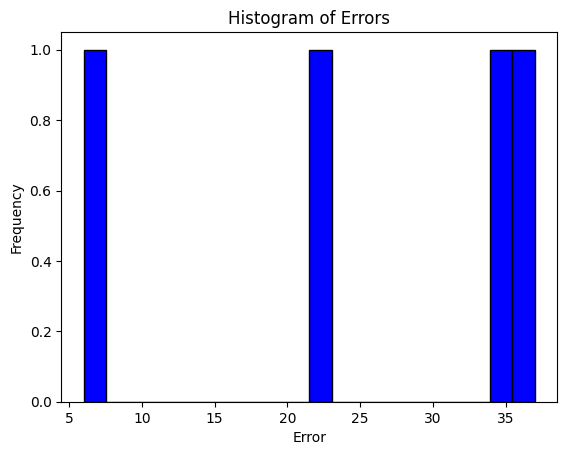

In [31]:
plot_errors(non_cot_results, title='Histogram of Errors', xlabel='Error', ylabel='Frequency') # make sure non_cot_results is defined by running it through the inference loop

Calculate the mean absolute error for each method and compare. This single number is a useful summary statistic to include in a paper's results table.

In [32]:
# Your code here
valid_cot_errors = [abs(result['numerical_true_answer'] - result['numerical_output_answer']) for result in cot_results if result['numerical_true_answer'] is not None and result['numerical_output_answer'] is not None]
mae_cot = sum(valid_cot_errors) / len(valid_cot_errors) if valid_cot_errors else 0

valid_non_cot_errors = [abs(result['numerical_true_answer'] - result['numerical_output_answer']) for result in non_cot_results if result['numerical_true_answer'] is not None and result['numerical_output_answer'] is not None]
mae_non_cot = sum(valid_non_cot_errors) / len(valid_non_cot_errors) if valid_non_cot_errors else 0

print(f"Mean Absolute Error (CoT): {mae_cot}")
print(f"Mean Absolute Error (non-CoT): {mae_non_cot}")

Mean Absolute Error (CoT): 67.312
Mean Absolute Error (non-CoT): 182.5


**Come up with your own analyses!** Some ideas:
- Do longer questions lead to more errors?
- Does CoT help more on multi-step problems vs. single-step ones?
- Is the model more accurate on questions with smaller numbers?
- Which question types (percentage, rate, etc.) cause the most failures?

**Think like a researcher:** what result would demonstrate that your method has promise? Maybe it makes fewer arithmetic errors, or handles longer reasoning chains better. Try to design analyses that could support (or refute) that claim.

Ask your mentor if you're unsure what analyses would be most convincing — this is hard without domain experience.

In [33]:
# Optional - Your code here for other analyses

# Using the OpenRouter API

Instead of running models locally (which requires a GPU), we can call powerful models through APIs. [OpenRouter](https://openrouter.ai) is a unified gateway that lets you access hundreds of models — including many **completely free** ones — through a single API endpoint.

**Why OpenRouter?**
- Free models available (no credit card needed for the free tier)
- Same interface as the OpenAI Python SDK — just change `base_url` and `api_key`
- Access to the latest open-source models: Llama 4, DeepSeek, Qwen, Gemini, and more

Get a free API key at: https://openrouter.ai/keys

In [34]:
!pip install openai

### Free Models on OpenRouter

Free model IDs always end in `:free`. Here are the current free models as of 2026 (this list changes over time — check https://openrouter.ai/models?q=:free for the latest):

**General / instruction-tuned (good for chat & CoT prompting):**

| Model | ID | Context |
|---|---|---|
| Meta Llama 3.3 70B | `meta-llama/llama-3.3-70b-instruct:free` | 65K |
| Mistral Small 3.1 24B | `mistralai/mistral-small-3.1-24b-instruct:free` | 128K |
| Qwen3 Next 80B | `qwen/qwen3-next-80b-a3b-instruct:free` | 262K |
| Arcee Trinity Large | `arcee-ai/trinity-large-preview:free` | 131K |

**Reasoning models (expose internal thinking trace):**

| Model | ID | Context |
|---|---|---|
| NVIDIA Nemotron 3 Super 120B | `nvidia/nemotron-3-super-120b-a12b:free` | 262K |
| OpenAI gpt-oss-120b | `openai/gpt-oss-120b:free` | 131K |
| MiniMax M2.5 | `minimax/minimax-m2.5:free` | 196K |
| Qwen3 4B | `qwen/qwen3-4b:free` | 41K |

Rate limits on free models: ~20 requests/minute, 200 requests/day — more than enough for experiments.

**Tip:** If a model is unavailable (rate limited), try `openrouter/free` — it automatically routes to a working free model.

In [35]:
from openai import OpenAI
from google.colab import userdata

# OpenRouter uses the same interface as the OpenAI SDK.
# Just swap base_url and use your OpenRouter API key.
client = OpenAI(
    api_key=userdata.get('YOUR_OPENROUTER_API_KEY'),  # Get a free key at: https://openrouter.ai/keys
    base_url="https://openrouter.ai/api/v1",
)

In [36]:
# Let's try a basic call with Llama 3.3 70B on a GSM8K question.
question = train_dataset[0]["question"]
print("Question:", question)

response = client.chat.completions.create(
    model="nvidia/nemotron-3-ultra-550b-a55b:free",
    messages=[
        {"role": "user", "content": question}
    ]
)

print("\nAnswer:", response.choices[0].message.content)

Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

Answer: Natalia sold **72** clips altogether.

Here is the breakdown:
1.  **April:** 48 clips
2.  **May:** Half of 48 = 24 clips
3.  **Total:** 48 + 24 = **72 clips**


### Modern API-based Inference Loop

Earlier we wrote an `inference_loop` that called `model.generate` locally. Here's the same idea refactored for API-based models — this is how real LLM research is done today. The key difference: instead of tokenizing and calling `model.generate`, we call `client.chat.completions.create`.

In [43]:
def api_inference_loop(prompt_function, model="openrouter/free"):
    """Modern API-based inference loop. Works with any OpenRouter model."""
    results = []
    correct_answers, total_questions = 0, 0

    for batch in debug_dataloader:  # swap to test_dataloader for the full benchmark
        question = batch['question'][0]
        true_answer = batch['answer'][0]

        prompt = prompt_function(question)

        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}]
        )
        output_answer = response.choices[0].message.content

        numerical_output_answer = extract_output_numerical_answer(output_answer)
        numerical_true_answer = extract_true_numerical_answer(true_answer)
        is_correct = (numerical_output_answer == numerical_true_answer)

        correct_answers += int(is_correct)
        total_questions += 1

        results.append({
            "question": question,
            "true_answer": true_answer,
            "output_answer": output_answer,
            "numerical_output_answer": numerical_output_answer,
            "numerical_true_answer": numerical_true_answer,
            "correct": is_correct,
        })

    accuracy = correct_answers / total_questions if total_questions > 0 else 0
    print(f"Accuracy: {correct_answers}/{total_questions} = {accuracy:.1%}")
    return results

In [44]:
# Run CoT prompting with Llama 4 via API
api_cot_results = api_inference_loop(cot_prompt_function)
api_cot_results

Accuracy: 2/5 = 40.0%


[{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
  'true_answer': 'Natalia sold 48/2 = 48/2=2424 clips in May.\nNatalia sold 48+24 = 48+24=7272 clips altogether in April and May.\n#### 72',
  'output_answer': 'Natalia sold 48 clips in April; in May she sold half that amount, which is  \n\n\\[\n\\frac{1}{2}\\times 48 = 24\n\\]\n\nclips.  \n\nSo the total number of clips sold in both months is  \n\n\\[\n48 + 24 = 72.\n\\]\n\n**Answer: 72 clips**',
  'numerical_output_answer': None,
  'numerical_true_answer': 72.0,
  'correct': False},
 {'question': 'Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?',
  'true_answer': 'Weng earns 12/60 = $12/60=0.20.2 per minute.\nWorking 50 minutes, she earned 0.2 x 50 = $0.2*50=1010.\n#### 10',
  'output_answer': '\nWeng earns $12 per hour, so her earnings per minute a

# Reasoning Models

A new class of LLMs called **reasoning models** produce an explicit internal chain-of-thought *before* giving a final answer. Unlike standard CoT prompting (where we prepend examples to guide the model), reasoning models are trained with reinforcement learning to reason on their own.

Key differences from standard LLMs:
- They "think" internally before answering — the thinking trace can be seconds to minutes long
- Their thinking trace is exposed via `response.choices[0].message.reasoning`
- You don't need to provide CoT examples — they do it automatically
- Generally much better at math, coding, and logical reasoning

**Free reasoning models we'll use:**
- `nvidia/nemotron-3-super-120b-a12b:free` — NVIDIA's 120B MoE reasoning model (262K context)
- `openai/gpt-oss-120b:free` — OpenAI's open-source 120B reasoning model
- `minimax/minimax-m2.5:free` — MiniMax's reasoning model, strong on math

**Background:** The reasoning model paradigm was popularized by OpenAI's o1 (2024) and open-sourced variants like DeepSeek-R1. Paper: https://arxiv.org/abs/2501.12948

In [45]:
# NVIDIA Nemotron 3 Super: a free 120B reasoning model with visible thinking trace
question = train_dataset[0]["question"]
print("Question:", question)

response = client.chat.completions.create(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    messages=[
        {"role": "user", "content": question}
    ],
    extra_body={"reasoning": {"effort": "high"}}  # request the thinking trace
)

print("\n=== THINKING TRACE ===")
print(response.choices[0].message.reasoning)

print("\n=== FINAL ANSWER ===")
print(response.choices[0].message.content)

Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

=== THINKING TRACE ===
We need to parse: Natalia sold clips to 48 friends in April, then she sold half as many clips in May. Means in May she sold half as many as she sold in April (i.e., half of 48 = 24). So total = 48 + 24 = 72. Answer: 72 clips.

We can respond succinctly.



=== FINAL ANSWER ===
Natalia sold \(48\) clips in April.  
In May she sold half as many: \(\frac{1}{2}\times48 = 24\) clips.  

Total clips sold = \(48 + 24 = 72\).

**Answer: 72 clips**.


Notice how the reasoning model produces a detailed thinking trace automatically — without any CoT examples in the prompt. This is what makes reasoning models so powerful for tasks like math and logic.

Now let's compare the two approaches head-to-head on the same question:

In [46]:
# Side-by-side: CoT-prompted Llama 3.3 vs. Nemotron reasoning model
question = debug_dataloader.dataset[0]['question']
print("Question:", question)
print("=" * 60)

# Method 1: Standard model + CoT prompt
cot_response = client.chat.completions.create(
    model="openrouter/free",
    messages=[{"role": "user", "content": cot_prompt_function(question)}]
)
print("CoT-Prompted Llama 3.3 Answer:")
print(cot_response.choices[0].message.content)
print()

# Method 2: Reasoning model (no special prompt needed)
reasoning_response = client.chat.completions.create(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    messages=[{"role": "user", "content": question}],
    extra_body={"reasoning": {"effort": "high"}}
)
print("Nemotron Reasoning Model Answer:")
print(reasoning_response.choices[0].message.content)
print("\nNemotron Thinking Trace (first 500 chars):")
print(reasoning_response.choices[0].message.reasoning[:500] if reasoning_response.choices[0].message.reasoning else "(no trace)")

Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
CoT-Prompted Llama 3.3 Answer:
A: Natalia sold 48 clips in April. In May, she sold half as many, which is 48 / 2 = 24 clips. To find the total, we add the clips from April and May: 48 + 24 = 72 clips. The answer is 72.

Nemotron Reasoning Model Answer:
Natalia sold 48 clips in April. In May she sold half as many, which is \( \frac{48}{2} = 24 \) clips.  

Total clips sold in April and May: \(48 + 24 = 72\).

**Answer: 72 clips**.

Nemotron Thinking Trace (first 500 chars):
We need to read the problem: Natalia sold clips to 48 of her friends in April, then she sold half as many clips in May. So in May she sold half of 48 = 24. Total = 48 + 24 = 72 clips.

We need to answer: 72.

We should give answer succinctly.




In [47]:
# Run the inference loop with the reasoning model — no CoT prompt needed!
def no_prompt_function(question):
    return question  # just pass the raw question

reasoning_results = api_inference_loop(no_prompt_function, model="nvidia/nemotron-3-super-120b-a12b:free")
reasoning_results

Accuracy: 0/5 = 0.0%


[{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
  'true_answer': 'Natalia sold 48/2 = 48/2=2424 clips in May.\nNatalia sold 48+24 = 48+24=7272 clips altogether in April and May.\n#### 72',
  'output_answer': 'Natalia sold  \n\n- **April:** 48 clips  \n- **May:** half as many as in April → \\(48 ÷ 2 = 24\\) clips  \n\nTotal clips sold in both months:  \n\n\\(48 + 24 = 72\\)\n\n**Answer: 72 clips**.',
  'numerical_output_answer': None,
  'numerical_true_answer': 72.0,
  'correct': False},
 {'question': 'Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?',
  'true_answer': 'Weng earns 12/60 = $12/60=0.20.2 per minute.\nWorking 50 minutes, she earned 0.2 x 50 = $0.2*50=1010.\n#### 10',
  'output_answer': 'Weng earns $12 per hour for babysitting. Since she worked 50 minutes, we first convert this time into

# LLM Agents

So far we've been prompting LLMs to produce an answer in one shot. **Agents** take this further: the model can take *actions* (like calling tools) and observe results, looping until it has a final answer.

The **ReAct** pattern (Yao et al., 2022) formalizes this as:
```
Thought → Action (tool call) → Observation (tool result) → Thought → ... → Final Answer
```

For math problems, we can give the agent a **calculator tool**. Instead of asking the model to do arithmetic in its head, it can call the calculator for each step — much more reliable!

How tool calling works:
1. We describe our tools as JSON schemas
2. The model returns a `tool_calls` message when it wants to use a tool
3. We run the tool and return the result as a `"role": "tool"` message
4. The model reads the result and continues reasoning
5. When done, `finish_reason == "stop"` and `message.content` has the final answer

**Paper:** ReAct: https://arxiv.org/abs/2210.03629

In [48]:
import json

# Define the tools available to our agent.
# Each tool is described as a JSON schema — the model reads this to know what tools exist.
tools = [
    {
        "type": "function",
        "function": {
            "name": "calculator",
            "description": "Evaluate a Python math expression. E.g. '17 * 23' or '(15 + 6) / 3 + 100'.",
            "parameters": {
                "type": "object",
                "properties": {
                    "expression": {
                        "type": "string",
                        "description": "A valid Python arithmetic expression to evaluate"
                    }
                },
                "required": ["expression"]
            }
        }
    }
]

# The actual Python implementation of each tool.
def calculator(expression: str) -> str:
    try:
        result = eval(expression, {"__builtins__": {}}, {})
        return str(result)
    except Exception as e:
        return f"Error: {e}"

TOOL_MAP = {"calculator": calculator}

# Quick test
print(calculator("17 * 23"))  # should print 391

391


In [51]:
def run_math_agent(question: str, model="openrouter/free", max_steps=8, verbose=True):
    """
    ReAct-style agent that solves a math problem using tool calling.

    Loop:
      - LLM sees the question and decides whether to call a tool or give a final answer
      - If finish_reason == 'tool_calls': execute the tool(s) and feed results back
      - If finish_reason == 'stop': return the final answer
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a precise math problem solver. "
                "Use the calculator tool to evaluate any arithmetic expressions — don't try to compute in your head. "
                "Show your reasoning step by step, then give the final numeric answer."
            )
        },
        {"role": "user", "content": question}
    ]

    for step in range(max_steps):
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            tools=tools,
            tool_choice="auto",  # model decides when to use tools
        )

        msg = response.choices[0].message
        finish_reason = response.choices[0].finish_reason

        # Add the model's response to the conversation history
        messages.append(msg)

        if finish_reason == "tool_calls":
            # The model wants to call one or more tools
            for tc in msg.tool_calls:
                fn_name = tc.function.name
                fn_args = json.loads(tc.function.arguments)
                if verbose:
                    print(f"  [Step {step+1}] Tool: {fn_name}({fn_args})")
                result = TOOL_MAP[fn_name](**fn_args)
                if verbose:
                    print(f"  [Step {step+1}] Result: {result}")
                # Feed the tool result back to the model
                messages.append({
                    "role": "tool",
                    "tool_call_id": tc.id,
                    "content": result
                })

        elif finish_reason == "stop":
            # The model has a final answer
            if verbose:
                print(f"\nFinal Answer: {msg.content}")
            return msg.content

    return "Max steps reached without a final answer"

In [52]:
# Try the agent on the first 3 debug questions
for i in range(3):
    q = debug_dataloader.dataset[i]['question']
    true_ans = debug_dataloader.dataset[i]['answer']
    print(f"\nQ{i+1}: {q}")
    print(f"True answer: {true_ans}")
    print("Agent:")
    run_math_agent(q)
    print("=" * 60)


Q1: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
True answer: Natalia sold 48/2 = 48/2=2424 clips in May.
Natalia sold 48+24 = 48+24=7272 clips altogether in April and May.
#### 72
Agent:
  [Step 1] Tool: calculator({'expression': '48 + 48 / 2'})
  [Step 1] Result: 72.0

Final Answer: Natalia sold 48 clips in April. In May, she sold half as many, which is 48 ÷ 2 = 24 clips. Adding those together:  
**48 + 24 = 72 clips total**.  

Final answer: **72**


Q2: Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?
True answer: Weng earns 12/60 = $12/60=0.20.2 per minute.
Working 50 minutes, she earned 0.2 x 50 = $0.2*50=1010.
#### 10
Agent:
  [Step 1] Tool: calculator({'expression': '12 * (50 / 60)'})
  [Step 1] Result: 10.0

Final Answer: \boxed{10}

Q3: Betty is saving money for a new wallet which costs $100. Betty has

### Comparing Agent Accuracy vs. Standard Prompting

Let's run the agent over our debug set and compare accuracy to the standard API inference loop.

In [57]:
def agent_inference_loop(model="openrouter/free"):
    """Runs the ReAct agent over the debug dataset and reports accuracy."""
    results = []
    correct_answers, total_questions = 0, 0

    for batch in debug_dataloader:
        question = batch['question'][0]
        true_answer = batch['answer'][0]

        output_answer = run_math_agent(question, model=model, verbose=False)

        numerical_output_answer = extract_output_numerical_answer(output_answer or "")
        numerical_true_answer = extract_true_numerical_answer(true_answer)
        is_correct = (numerical_output_answer == numerical_true_answer)

        correct_answers += int(is_correct)
        total_questions += 1

        results.append({
            "question": question,
            "true_answer": true_answer,
            "output_answer": output_answer,
            "numerical_output_answer": numerical_output_answer,
            "numerical_true_answer": numerical_true_answer,
            "correct": is_correct,
        })

    accuracy = correct_answers / total_questions if total_questions > 0 else 0
    print(f"Agent Accuracy: {correct_answers}/{total_questions} = {accuracy:.1%}")
    return results

agent_results = agent_inference_loop()

Agent Accuracy: 0/5 = 0.0%


In [58]:
# Quick comparison summary
# Compare: standard CoT prompt vs. reasoning model vs. tool-calling agent
methods = {
    "CoT Prompted (Llama 3.3 70B)": api_cot_results,
    "Reasoning Model (Nemotron 120B)": reasoning_results,
    "Tool-Calling Agent (Mistral Small)": agent_results,
}

for method_name, res in methods.items():
    correct = sum(1 for r in res if r['correct'])
    total = len(res)
    print(f"{method_name}: {correct}/{total} = {correct/total:.1%}")

CoT Prompted (Llama 3.3 70B): 2/5 = 40.0%
Reasoning Model (Nemotron 120B): 0/5 = 0.0%
Tool-Calling Agent (Mistral Small): 0/5 = 0.0%


# (Optional) Reasoning Model + Tool Calling

Some reasoning models also support tool calling — combining deep internal reasoning *and* the ability to use tools. The following free models support both `reasoning` and `tools`:

- `nvidia/nemotron-3-super-120b-a12b:free`
- `openai/gpt-oss-120b:free`
- `minimax/minimax-m2.5:free`
- `nvidia/nemotron-3-nano-30b-a3b:free`

Try combining a reasoning model with the calculator tool:

In [56]:
# Optional: combine a reasoning model with tool calling

def run_reasoning_agent(question: str):
    """Agent using a reasoning model + calculator tool."""
    return run_math_agent(question, model="openrouter/free", verbose=True)

# Try it out
run_reasoning_agent(debug_dataloader.dataset[0]['question'])


Final Answer: Natalia sold \(\displaystyle 48\) clips in April.  
In May she sold half as many, so

\[
\frac{1}{2}\times 48 = 24 \text{ clips}.
\]

Total clips sold in April and May:

\[
48 + 24 = 72.
\]

**Answer: 72 clips.**


'Natalia sold \\(\\displaystyle 48\\) clips in April.  \nIn May she sold half as many, so\n\n\\[\n\\frac{1}{2}\\times 48 = 24 \\text{ clips}.\n\\]\n\nTotal clips sold in April and May:\n\n\\[\n48 + 24 = 72.\n\\]\n\n**Answer: 72 clips.**'

# (Optional) Self-Consistency

Self-consistency (Wang et al., 2022) improves accuracy by sampling multiple reasoning paths and taking a majority vote over the final answers. Instead of one call per question, you make N calls and pick the most common answer.

Try implementing this with any of the API methods above:
- Call the model N times (e.g. N=5) with `temperature > 0`
- Extract the numerical answer from each output
- Return the majority answer

Paper: https://arxiv.org/abs/2203.11171

In [ ]:
# Your code here — implement self-consistency with the API

# That's it! Congratulations on finishing this — this was a lot :)

You've now covered:
1. Running local models (Phi-1.5B) with HuggingFace Transformers
2. Prompt engineering: zero-shot, few-shot, and chain-of-thought
3. API-based inference with OpenRouter free models (Llama 3.3, Mistral Small, Qwen3, etc.)
4. Reasoning models with internal thinking traces (NVIDIA Nemotron, OpenAI gpt-oss, MiniMax M2.5)
5. ReAct agents with tool calling

These are the core building blocks of modern LLM research and engineering.